# LogGuardian — Modèle de détection d'anomalies

Le modèle est un **LSTM Autoencoder** entraîné uniquement sur des logs normaux.

**Principe** : si le modèle reconstruit mal une séquence → c'est une anomalie.

---

## 1. Chargement

In [33]:
import sys
sys.path.insert(0, "src")

import json, pickle, warnings
warnings.filterwarnings("ignore")

import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

from trainer.dataset import prepare_datasets
from trainer.model import LSTMAutoencoder

plt.rcParams["figure.dpi"] = 110

# Chargement des artefacts
with open("models/threshold.json") as f:
    meta = json.load(f)

with open("models/vocabulary.pkl", "rb") as f:
    vocab = pickle.load(f)

with open("models/feature_scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

embedding_table = np.load("models/embedding_table.npy")

model = LSTMAutoencoder(
    n_features=meta["n_features"],
    hidden_size=meta["hidden_size"],
    latent_size=meta["latent_size"],
    seq_len=meta["seq_len"],
)
model.load_state_dict(torch.load("models/lstm_autoencoder.pt", map_location="cpu", weights_only=True))
model.eval()

print(f"Modèle chargé")
print(f"Seuil d'anomalie : {meta['threshold']:.4f}")
print(f"Train loss : {meta['train_loss']:.4f} | Val loss : {meta['val_loss']:.4f}")

Modèle chargé
Seuil d'anomalie : 1.3072
Train loss : 0.2696 | Val loss : 0.2641


## 2. Données

In [34]:
train_seqs, val_seqs, all_seqs, all_labels, _, _, _ = prepare_datasets(
    parquet_dir="../data/etl-output",
    seq_len=meta["seq_len"],
)

print(f"Séquences totales  : {len(all_seqs):,}")
print(f"  Normales         : {(~all_labels).sum():,}")
print(f"  Anomalies        : {all_labels.sum():,}")

Séquences totales  : 645,482
  Normales         : 581,332
  Anomalies        : 64,150


## 3. Scores de reconstruction

On passe toutes les séquences dans le modèle et on calcule l'erreur MSE.

In [35]:
tensor  = torch.tensor(all_seqs, dtype=torch.float32)
loader  = DataLoader(TensorDataset(tensor), batch_size=256)
scores  = []

with torch.no_grad():
    for (batch,) in loader:
        scores.extend(model.reconstruction_error(batch).numpy())

scores    = np.array(scores)
threshold = meta["threshold"]
detected  = scores > threshold

print(f"Anomalies détectées : {detected.sum():,} / {len(scores):,} ({detected.mean()*100:.1f}%)")

Anomalies détectées : 140,209 / 645,482 (21.7%)


## 4. Distribution des scores

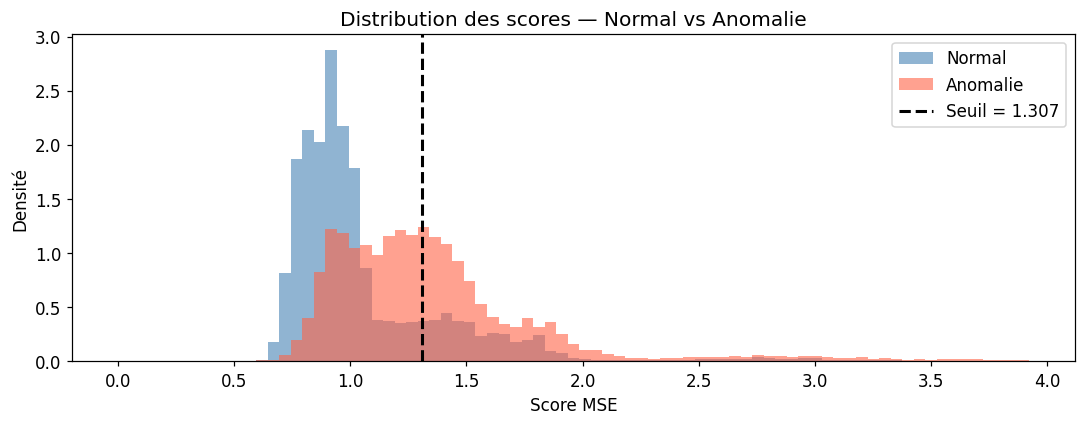

In [36]:
bins = np.linspace(0, min(scores.max(), threshold * 3), 80)

plt.figure(figsize=(10, 4))
plt.hist(scores[~all_labels], bins=bins, alpha=0.6, label="Normal",   color="steelblue", density=True)
plt.hist(scores[ all_labels], bins=bins, alpha=0.6, label="Anomalie", color="tomato",    density=True)
plt.axvline(threshold, color="black", linestyle="--", linewidth=2, label=f"Seuil = {threshold:.3f}")
plt.xlabel("Score MSE")
plt.ylabel("Densité")
plt.title("Distribution des scores — Normal vs Anomalie")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Performances

              precision    recall  f1-score   support

      Normal       0.93      0.81      0.87    581332
    Anomalie       0.21      0.46      0.29     64150

    accuracy                           0.77    645482
   macro avg       0.57      0.63      0.58    645482
weighted avg       0.86      0.77      0.81    645482



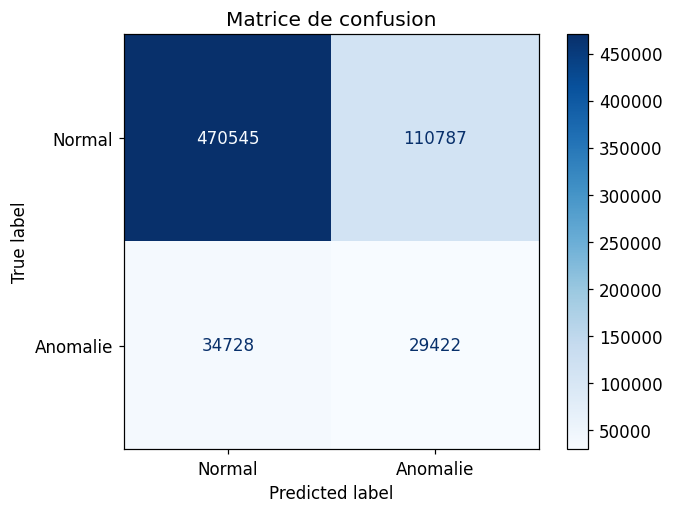

In [37]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix

preds = detected.astype(int)
truth = all_labels.astype(int)

print(classification_report(truth, preds, target_names=["Normal", "Anomalie"]))

ConfusionMatrixDisplay(confusion_matrix(truth, preds), display_labels=["Normal", "Anomalie"]).plot(cmap="Blues")
plt.title("Matrice de confusion")
plt.tight_layout()
plt.show()